# Pooled Xenium Pancreas/PDAC Niche Pseudotime

This notebook fits a pooled epithelial-niche trajectory across three 10x Xenium PDAC datasets and one nondiseased pancreas dataset.

Interpretation guardrail:

This is a cross-sample **morphologic/transcriptomic spatial continuum**, not literal patient time. The value is that SpatioEv can align normal-like, PanIN-like, proliferative, desmoplastic, and immune-remodeled epithelial niches onto a shared tree.


In [1]:

%matplotlib inline

import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path
import gc
import json
import importlib.util
import tarfile
import warnings
from io import StringIO

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 8
sns.set_style("white")

ROOT = Path("/Users/shihongwu/SpatioEv")
DATA_ROOT = Path("/Volumes/Shihong_5/for_spatioev/pancreas_Xenium_example_data_from_10X")
OUTPUT_DIR = ROOT / "data" / "xenium_pancreas_10x"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_CONFIGS = [
    {
        "sample_id": "pdac_pancreas_v1",
        "display_name": "Human Pancreas FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_human_Pancreas_FFPE_outs",
    },
    {
        "sample_id": "pdac_io_v1",
        "display_name": "Human Ductal Adenocarcinoma FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Immuno-Oncology",
        "outs_path": DATA_ROOT / "Xenium_V1_Human_Ductal_Adenocarcinoma_FFPE_outs",
    },
    {
        "sample_id": "pdac_addon_v1",
        "display_name": "hPancreas Cancer Add-on FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue + Add-on",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_Cancer_Add_on_FFPE_outs",
    },
    {
        "sample_id": "normal_nondiseased_v1",
        "display_name": "hPancreas nondiseased section",
        "disease_group": "NormalPancreas",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_nondiseased_section_outs",
    },
]

def package_available(name):
    return importlib.util.find_spec(name) is not None

def save_df(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".pkl":
        df.to_pickle(path)
    else:
        df.to_csv(path, index=index)

def load_df(path):
    path = Path(path)
    if path.suffix == ".pkl":
        return pd.read_pickle(path)
    return pd.read_csv(path)

def present_columns(df, cols):
    return [c for c in cols if c in df.columns]

def make_sparse_safe_copy(X):
    return X.copy() if sparse.issparse(X) else np.asarray(X).copy()


In [2]:

import elpigraph
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from umap import UMAP

NICHE_KEY = "xenium_ductal_epithelium_component"
NICHE_DIR = OUTPUT_DIR / "niche_features"
RESULT_DIR = OUTPUT_DIR / "pseudotime"
RESULT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
SIMPLIFIED_NUM_NODES = 24
DETAILED_TREE_MIN_NODES = 40
DETAILED_TREE_MAX_NODES = 100
DETAILED_TREE_NODE_SCALE = 2.5
EXPECTED_NICHE_FEATURE_VERSION = "boundary_components_v2"
EXPECTED_DAPI_FEATURE_VERSION = "user_verified_focus_dapi_sources_v2"
EXPECTED_ANNOTATION_VERSION = "cluster_full_panel_v9_xenium_graphclust_io_mucosa_submucosa_k24"

pooled_niche_feature_df = load_df(OUTPUT_DIR / "pooled_xenium_niche_feature_df.pkl")
print(pooled_niche_feature_df.shape)

version_cols = [
    col for col in [
        "sample_id",
        "xenium_annotation_version",
        "xenium_niche_feature_version",
        "xenium_dapi_feature_version",
    ]
    if col in pooled_niche_feature_df.columns
]
if len(version_cols) > 1:
    version_summary_df = pooled_niche_feature_df[version_cols].drop_duplicates().sort_values("sample_id")
    display(version_summary_df)
else:
    print("No upstream version metadata found. Rerun notebook 02 with the current workflow before final interpretation.")

if "xenium_annotation_version" in pooled_niche_feature_df.columns:
    annotation_versions = set(pooled_niche_feature_df["xenium_annotation_version"].dropna().astype(str))
    if annotation_versions != {EXPECTED_ANNOTATION_VERSION}:
        print(f"Warning: annotation versions differ from expected {EXPECTED_ANNOTATION_VERSION}: {sorted(annotation_versions)}")
else:
    print("Warning: xenium_annotation_version is missing; rerun notebook 02 after notebook 01.")

if "xenium_niche_feature_version" in pooled_niche_feature_df.columns:
    niche_versions = set(pooled_niche_feature_df["xenium_niche_feature_version"].dropna().astype(str))
    if niche_versions != {EXPECTED_NICHE_FEATURE_VERSION}:
        print(f"Warning: niche feature versions differ from expected {EXPECTED_NICHE_FEATURE_VERSION}: {sorted(niche_versions)}")

if "xenium_dapi_feature_version" in pooled_niche_feature_df.columns:
    dapi_versions = set(pooled_niche_feature_df["xenium_dapi_feature_version"].fillna("none").astype(str))
    if dapi_versions == {"none"}:
        print("DAPI full epithelial features are not included yet. This is OK for a first run; run full DAPI extraction in notebook 02 to include nuclear texture.")
    elif dapi_versions != {EXPECTED_DAPI_FEATURE_VERSION}:
        print(f"Warning: DAPI feature versions differ from expected {EXPECTED_DAPI_FEATURE_VERSION}: {sorted(dapi_versions)}")

pooled_niche_feature_df.head()


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5074, 2115)


,sample_id,xenium_annotation_version,xenium_niche_feature_version,xenium_dapi_feature_version
3297,normal_nondiseased_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v2,user_verified_focus_dapi_sources_v2
2082,pdac_addon_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v2,user_verified_focus_dapi_sources_v2
1495,pdac_io_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v2,user_verified_focus_dapi_sources_v2
0,pdac_pancreas_v1,cluster_full_panel_v9_xenium_graphclust_io_muc...,boundary_components_v2,user_verified_focus_dapi_sources_v2


,xenium_ductal_epithelium_component,image_id,n_cells,topology__n_nodes,topology__n_edges,topology__density,topology__avg_degree,topology__degree_var,topology__degree_cv,topology__leaf_fraction,...,surround__Myeloid_cells__CSF1R_expr_z__median,surround__Myeloid_cells__S100A9_expr_z__n_cells,surround__Myeloid_cells__S100A9_expr_z__mean,surround__Myeloid_cells__S100A9_expr_z__median,surround__Myeloid_cells__CXCR2_expr_z__n_cells,surround__Myeloid_cells__CXCR2_expr_z__mean,surround__Myeloid_cells__CXCR2_expr_z__median,surround__Myeloid_cells__ITGAX_expr_z__n_cells,surround__Myeloid_cells__ITGAX_expr_z__mean,surround__Myeloid_cells__ITGAX_expr_z__median
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,6.0,6.0,15.0,1.000000,5.000000,0.000000,0.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,155.0,155.0,1402.0,0.117470,18.090323,34.688616,0.325572,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,13.0,13.0,42.0,0.538462,6.461538,1.940828,0.215604,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,10.0,10.0,38.0,0.844444,7.600000,1.640000,0.168503,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,11.0,11.0,40.0,0.727273,7.272727,3.107438,0.242384,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:

MODULE_COLS = [
    "xenium_epithelial_identity_score",
    "xenium_panin_like_remodeling_score",
    "xenium_proliferation_score",
    "xenium_desmoplastic_context_score",
    "xenium_immune_context_score",
    "xenium_checkpoint_context_score",
    "xenium_nuclear_dapi_texture_score",
]

SUPPLEMENTAL_PATTERNS = [
    "geometry__",
    "topology__skeleton",
    "surround_prop__",
    "state__EPCAM",
    "state__KRT7",
    "state__SOX9",
    "state__MUC5AC",
    "state__TFF",
    "state__CEACAM6",
    "state__AGR3",
    "state__MKI67",
    "state__UBE2C",
    "state__TOP2A",
    "state__dapi_",
    "state__nucleus_boundary",
]

def prepare_feature_matrix(df, feature_cols, max_na_frac=0.45, corr_cutoff=0.97):
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    X = X.loc[:, X.isna().mean() <= max_na_frac]
    X = X.apply(lambda col: col.fillna(col.median()), axis=0)
    X = X.loc[:, X.var(ddof=0) > 1e-8]

    priority = [c for c in MODULE_COLS if c in X.columns]
    candidates = [c for c in X.columns if c not in priority]
    corr_abs = X.corr().abs()
    selected = list(priority)
    for col in candidates:
        if not selected:
            selected.append(col)
            continue
        max_corr = corr_abs.loc[col, selected].dropna().max()
        if not np.isfinite(max_corr) or max_corr < corr_cutoff:
            selected.append(col)
    return X[selected].copy(), selected

candidate_cols = []
for col in pooled_niche_feature_df.columns:
    if col in MODULE_COLS:
        candidate_cols.append(col)
    elif any(col.startswith(pattern) for pattern in SUPPLEMENTAL_PATTERNS):
        candidate_cols.append(col)

X_pool, selected_cols = prepare_feature_matrix(pooled_niche_feature_df, candidate_cols)
print(f"Selected {len(selected_cols)} trajectory features")
pd.Series(selected_cols, name="feature").to_frame().head(25)


Selected 260 trajectory features


,feature
0,xenium_epithelial_identity_score
1,xenium_panin_like_remodeling_score
2,xenium_proliferation_score
3,xenium_desmoplastic_context_score
4,xenium_immune_context_score
5,xenium_checkpoint_context_score
6,xenium_nuclear_dapi_texture_score
7,topology__skeleton_n_edges
8,topology__skeleton_leaf_fraction
9,topology__skeleton_branchpoint_fraction


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


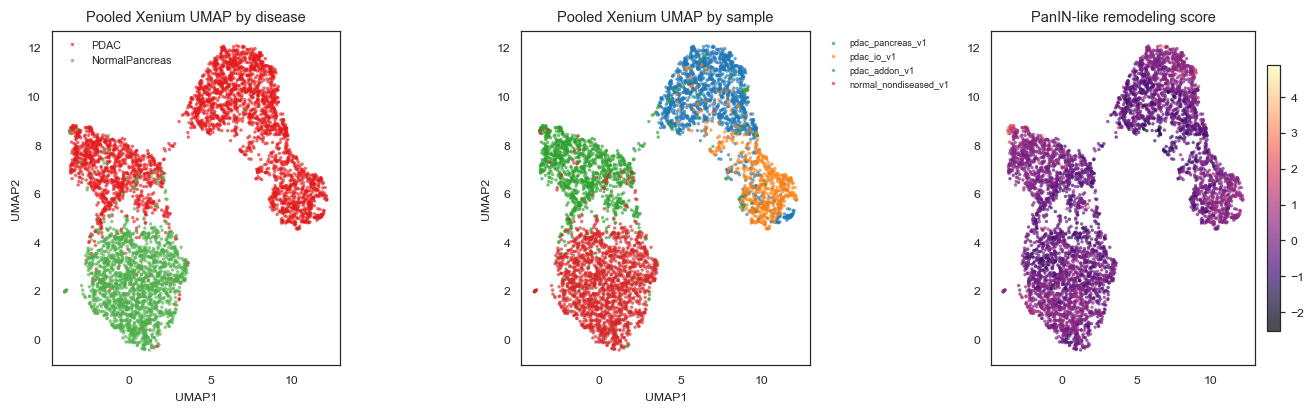

In [4]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pool)

pca = PCA(n_components=min(12, X_scaled.shape[1]), random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
X_pca_use = X_pca[:, : min(6, X_pca.shape[1])]

umap_model = UMAP(
    n_neighbors=15,
    min_dist=0.20,
    n_components=2,
    random_state=RANDOM_STATE,
)
X_umap = umap_model.fit_transform(X_pca_use)

embedding_df = pooled_niche_feature_df[[NICHE_KEY, "sample_id", "display_name", "disease_group"]].copy()
embedding_df["UMAP1"] = X_umap[:, 0]
embedding_df["UMAP2"] = X_umap[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
sns.scatterplot(
    data=embedding_df,
    x="UMAP1",
    y="UMAP2",
    hue="disease_group",
    palette={"NormalPancreas": "#4daf4a", "PDAC": "#e41a1c"},
    s=5,
    linewidth=0,
    alpha=0.65,
    ax=axes[0],
)
axes[0].set_title("Pooled Xenium UMAP by disease")
axes[0].grid(False)
axes[0].legend(frameon=False, fontsize=7)

sns.scatterplot(
    data=embedding_df,
    x="UMAP1",
    y="UMAP2",
    hue="sample_id",
    palette="tab10",
    s=5,
    linewidth=0,
    alpha=0.65,
    ax=axes[1],
)
axes[1].set_title("Pooled Xenium UMAP by sample")
axes[1].grid(False)
axes[1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

scat = axes[2].scatter(
    embedding_df["UMAP1"],
    embedding_df["UMAP2"],
    c=pooled_niche_feature_df["xenium_panin_like_remodeling_score"],
    s=5,
    linewidth=0,
    alpha=0.7,
    cmap="magma",
)
axes[2].set_title("PanIN-like remodeling score")
axes[2].grid(False)
plt.colorbar(scat, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [5]:

reduced_data = X_pca_use
n_niches = reduced_data.shape[0]
num_nodes = int(
    min(
        DETAILED_TREE_MAX_NODES,
        max(DETAILED_TREE_MIN_NODES, np.ceil(np.sqrt(n_niches) * DETAILED_TREE_NODE_SCALE)),
    )
)
num_nodes = int(min(num_nodes, max(2, n_niches - 1)))
num_nodes_simple = int(min(SIMPLIFIED_NUM_NODES, max(2, n_niches - 1)))

pg_tree = elpigraph.computeElasticPrincipalTree(
    X=reduced_data,
    NumNodes=num_nodes,
    Lambda=0.005,
    Mu=0.01,
)[0]

pg_tree_simple = elpigraph.computeElasticPrincipalTree(
    X=reduced_data,
    NumNodes=num_nodes_simple,
    Lambda=0.005,
    Mu=0.01,
)[0]

root_score = pd.to_numeric(pooled_niche_feature_df["xenium_epithelial_identity_score"], errors="coerce")
normal_mask = pooled_niche_feature_df["disease_group"] == "NormalPancreas"
root_mask = normal_mask & (root_score >= root_score[normal_mask].quantile(0.85))
if root_mask.sum() == 0:
    root_mask = normal_mask
root_anchor = reduced_data[root_mask.to_numpy()].mean(axis=0)
source_node = int(np.argmin(np.sum((pg_tree["NodePositions"] - root_anchor) ** 2, axis=1)))
source_node_simple = int(np.argmin(np.sum((pg_tree_simple["NodePositions"] - root_anchor) ** 2, axis=1)))

elpigraph.utils.getPseudotime(
    X=reduced_data,
    PG=pg_tree,
    source=source_node,
    target=None,
)

elpigraph.utils.getPseudotime(
    X=reduced_data,
    PG=pg_tree_simple,
    source=source_node_simple,
    target=None,
)

projection = pg_tree["projection"]
projection_simple = pg_tree_simple["projection"]
result_df = embedding_df.copy()
result_df["xenium_pseudotime"] = pg_tree["pseudotime"]
result_df["xenium_node_id"] = projection["node_id"]
result_df["xenium_edge_id"] = projection["edge_id"]
result_df["xenium_simple_pseudotime"] = pg_tree_simple["pseudotime"]
result_df["xenium_simple_node_id"] = projection_simple["node_id"]
result_df["xenium_simple_edge_id"] = projection_simple["edge_id"]
for col in MODULE_COLS:
    if col in pooled_niche_feature_df.columns:
        result_df[col] = pooled_niche_feature_df[col].values

print("NumNodes (detailed tree):", num_nodes)
print("NumNodes (simplified tree):", num_nodes_simple)
print("Root niches:", int(root_mask.sum()))
print("Detailed root node:", source_node)
print("Simplified root node:", source_node_simple)
result_df.head()


NumNodes (detailed tree): 100
NumNodes (simplified tree): 24
Root niches: 267
Detailed root node: 68
Simplified root node: 21


,xenium_ductal_epithelium_component,sample_id,display_name,disease_group,UMAP1,UMAP2,xenium_pseudotime,xenium_node_id,xenium_edge_id,xenium_simple_pseudotime,xenium_simple_node_id,xenium_simple_edge_id,xenium_epithelial_identity_score,xenium_panin_like_remodeling_score,xenium_proliferation_score,xenium_desmoplastic_context_score,xenium_immune_context_score,xenium_checkpoint_context_score,xenium_nuclear_dapi_texture_score
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,8.925871,5.902560,22.594551,80,77,19.680915,22,19,0.411327,-0.193440,1.063498,1.092683,-0.687338,-0.360977,1.146233
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,10.697216,5.040128,27.299025,74,69,19.164133,22,19,0.627930,0.401430,0.797775,1.022966,0.925656,-0.330743,0.801687
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,9.518946,5.361968,19.722058,41,26,18.755399,22,19,1.471810,-0.139802,0.370625,0.972951,-0.212368,0.130757,0.618849
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,9.785358,4.855491,29.970357,86,83,24.377437,6,19,0.737255,-0.018592,4.228384,0.828356,-0.640156,0.343969,0.852054
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,8.882585,5.471994,22.594551,80,77,18.464050,22,19,0.767711,0.106994,0.003637,1.772549,2.217797,0.653788,1.158139


In [6]:

def tree_edges(pg_tree):
    edges = np.asarray(pg_tree["Edges"][0], dtype=int)
    return [tuple(map(int, edge)) for edge in edges]

def node_graph(pg_tree):
    G = nx.Graph()
    G.add_edges_from(tree_edges(pg_tree))
    return G

def infer_branch_labels(pg_tree, result_df, source_node, node_col="xenium_node_id"):
    G = node_graph(pg_tree)
    degrees = dict(G.degree())
    branch_nodes = [n for n, d in degrees.items() if d >= 3]
    hub = max(branch_nodes, key=lambda n: degrees[n]) if branch_nodes else source_node
    trunk_path = nx.shortest_path(G, source=source_node, target=hub)

    branch_paths = {}
    branch_i = 1
    for neighbor in sorted(G.neighbors(hub)):
        if neighbor in trunk_path:
            continue
        component = nx.node_connected_component(nx.Graph(G.copy().subgraph(set(G.nodes) - {hub})), neighbor)
        leaves = sorted([n for n in component if G.degree(n) == 1])
        if len(leaves) <= 1:
            end = leaves[0] if leaves else neighbor
            branch_paths[f"branch {branch_i}"] = [hub] + nx.shortest_path(G, source=neighbor, target=end)
            branch_i += 1
            continue
        for leaf in leaves:
            branch_paths[f"branch {branch_i}"] = [hub] + nx.shortest_path(G, source=neighbor, target=leaf)
            branch_i += 1

    node_to_branch = {n: "trunk" for n in trunk_path}
    for label, path in branch_paths.items():
        for n in path[1:]:
            node_to_branch[n] = label

    labels = result_df[node_col].map(node_to_branch).fillna("other")
    return labels.astype(str), {"hub_node": hub, "trunk_path": trunk_path, "branch_paths": branch_paths}

result_df["major_branch"], branch_defs = infer_branch_labels(
    pg_tree_simple,
    result_df,
    source_node_simple,
    node_col="xenium_simple_node_id",
)
print(branch_defs)


{'hub_node': 0, 'trunk_path': [21, 0], 'branch_paths': {'branch 1': [0, 3], 'branch 2': [0, 4], 'branch 3': [0, 7], 'branch 4': [0, 8, 14, 23, 5], 'branch 5': [0, 13, 19, 9, 2, 16], 'branch 6': [0, 15], 'branch 7': [0, 17, 11], 'branch 8': [0, 18, 1, 12], 'branch 9': [0, 20, 22, 6]}}


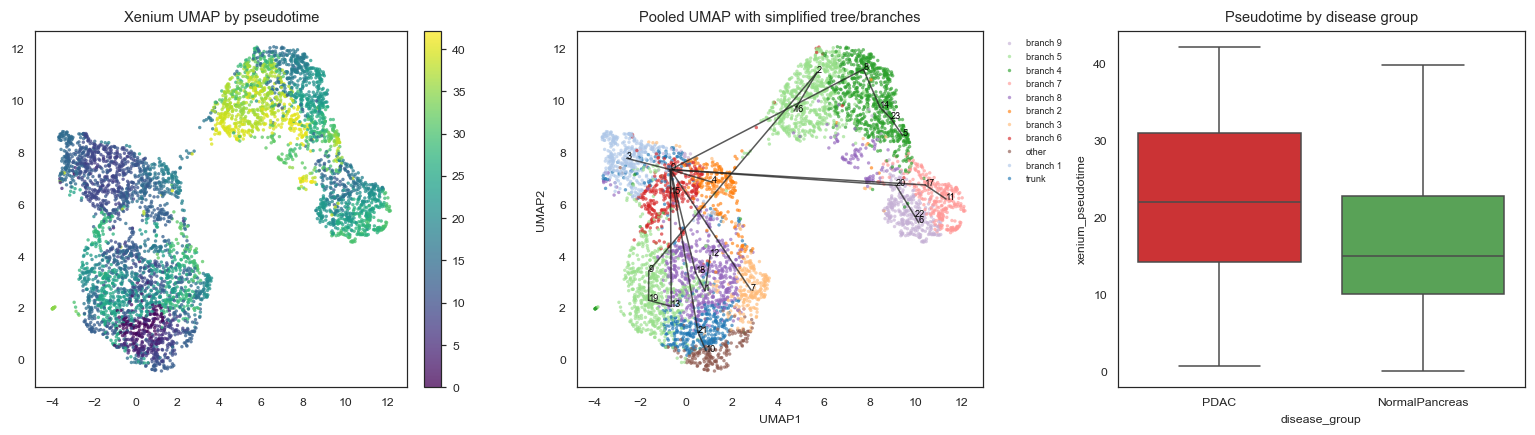

In [7]:

def compute_umap_tree_nodes(pg_tree, X_pca_use, X_umap):
    node_positions = pg_tree["NodePositions"]
    nbrs = NearestNeighbors(n_neighbors=min(60, len(X_pca_use))).fit(X_pca_use)
    node_umap = []
    for node_pos in node_positions:
        _, idx = nbrs.kneighbors(node_pos.reshape(1, -1))
        node_umap.append(np.median(X_umap[idx[0]], axis=0))
    return np.asarray(node_umap)

def plot_tree_overlay(ax, result_df, pg_tree, node_umap, color_col, palette=None, point_size=5):
    sns.scatterplot(
        data=result_df,
        x="UMAP1",
        y="UMAP2",
        hue=color_col,
        palette=palette,
        s=point_size,
        linewidth=0,
        alpha=0.65,
        ax=ax,
    )
    for u, v in tree_edges(pg_tree):
        ax.plot(
            [node_umap[u, 0], node_umap[v, 0]],
            [node_umap[u, 1], node_umap[v, 1]],
            color="#222222",
            linewidth=1.0,
            alpha=0.75,
        )
    for node, xy in enumerate(node_umap):
        ax.text(xy[0], xy[1], str(node), fontsize=6, color="black")
    ax.grid(False)

node_umap = compute_umap_tree_nodes(pg_tree_simple, reduced_data, X_umap)
branch_order = ["trunk"] + sorted([b for b in result_df["major_branch"].unique() if b not in {"trunk", "other"}]) + ["other"]
branch_palette = dict(zip(branch_order, sns.color_palette("tab20", n_colors=len(branch_order))))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
scat = axes[0].scatter(
    result_df["UMAP1"],
    result_df["UMAP2"],
    c=result_df["xenium_pseudotime"],
    s=5,
    linewidth=0,
    cmap="viridis",
    alpha=0.75,
)
axes[0].set_title("Xenium UMAP by pseudotime")
axes[0].grid(False)
plt.colorbar(scat, ax=axes[0], fraction=0.046, pad=0.04)

plot_tree_overlay(
    axes[1],
    result_df,
    pg_tree_simple,
    node_umap,
    color_col="major_branch",
    palette=branch_palette,
    point_size=5,
)
axes[1].set_title("Pooled UMAP with simplified tree/branches")
axes[1].legend(frameon=False, fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(
    data=result_df,
    x="disease_group",
    y="xenium_pseudotime",
    hue="disease_group",
    palette={"NormalPancreas": "#4daf4a", "PDAC": "#e41a1c"},
    legend=False,
    fliersize=0,
    ax=axes[2],
)
axes[2].set_title("Pseudotime by disease group")
axes[2].grid(False)

plt.tight_layout()
plt.show()


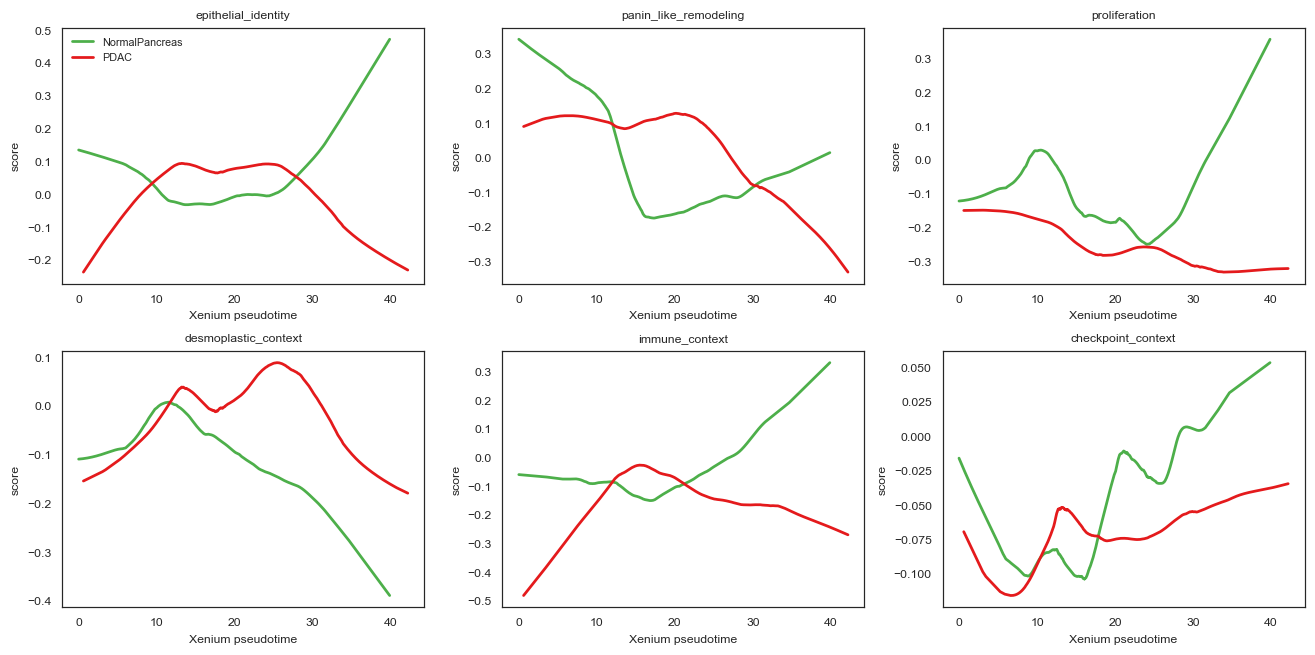

In [8]:

def lowess_or_line(x, y, frac=0.3):
    import statsmodels.api as sm
    tmp = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    if len(tmp) < 20:
        return tmp["x"].to_numpy(), tmp["y"].to_numpy()
    out = sm.nonparametric.lowess(tmp["y"], tmp["x"], frac=frac, return_sorted=True)
    return out[:, 0], out[:, 1]

trend_features = [
    "xenium_epithelial_identity_score",
    "xenium_panin_like_remodeling_score",
    "xenium_proliferation_score",
    "xenium_desmoplastic_context_score",
    "xenium_immune_context_score",
    "xenium_checkpoint_context_score",
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()
for ax, feature in zip(axes, trend_features):
    if feature not in result_df.columns:
        ax.axis("off")
        continue
    for disease, color in {"NormalPancreas": "#4daf4a", "PDAC": "#e41a1c"}.items():
        sub = result_df[result_df["disease_group"] == disease]
        x, y = lowess_or_line(sub["xenium_pseudotime"], sub[feature], frac=0.35)
        ax.plot(x, y, color=color, linewidth=1.8, label=disease)
    ax.set_title(feature.replace("xenium_", "").replace("_score", ""), fontsize=8)
    ax.set_xlabel("Xenium pseudotime")
    ax.set_ylabel("score")
    ax.grid(False)
axes[0].legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()


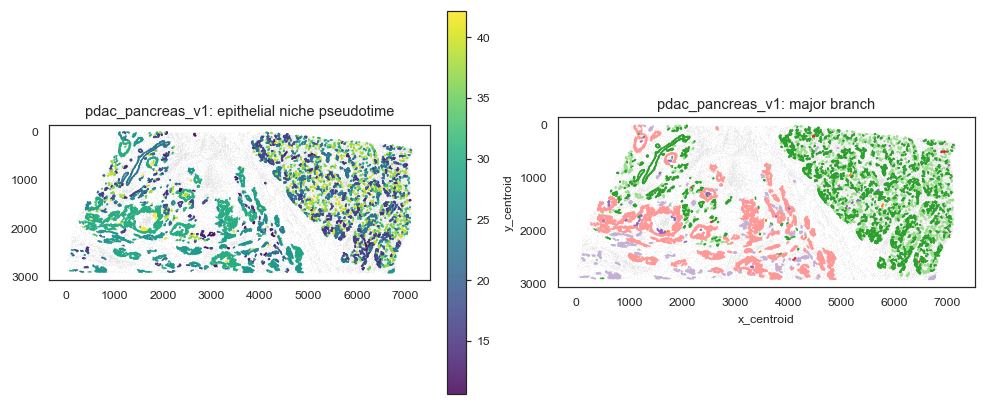

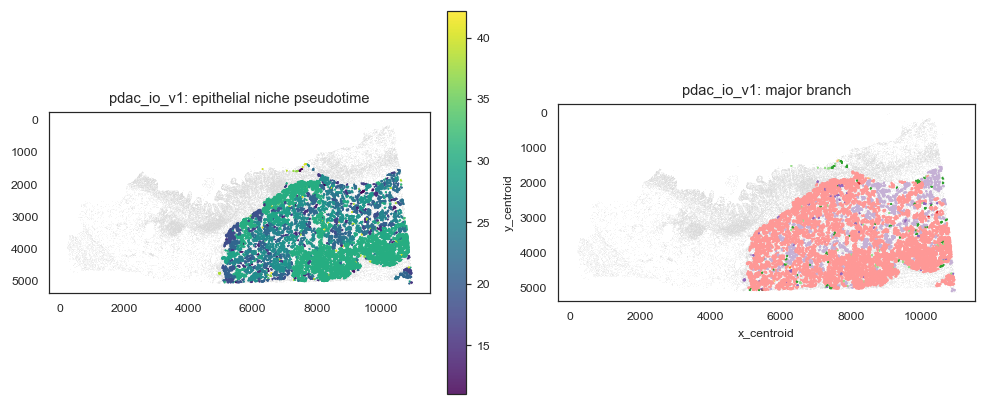

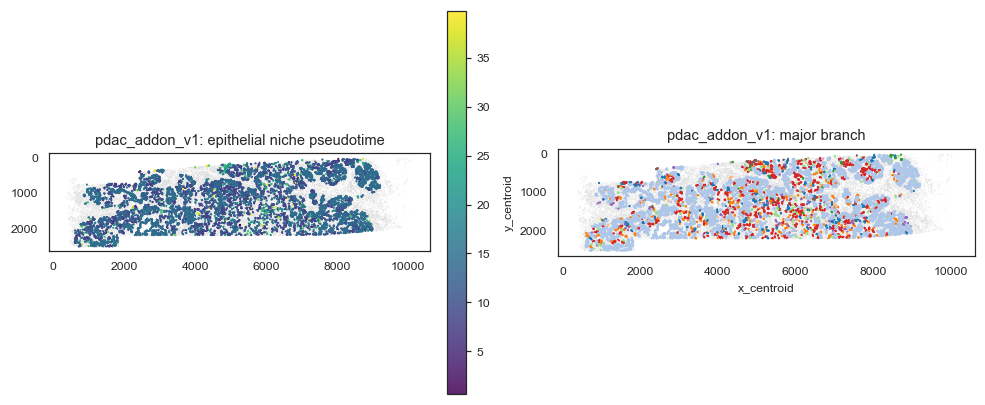

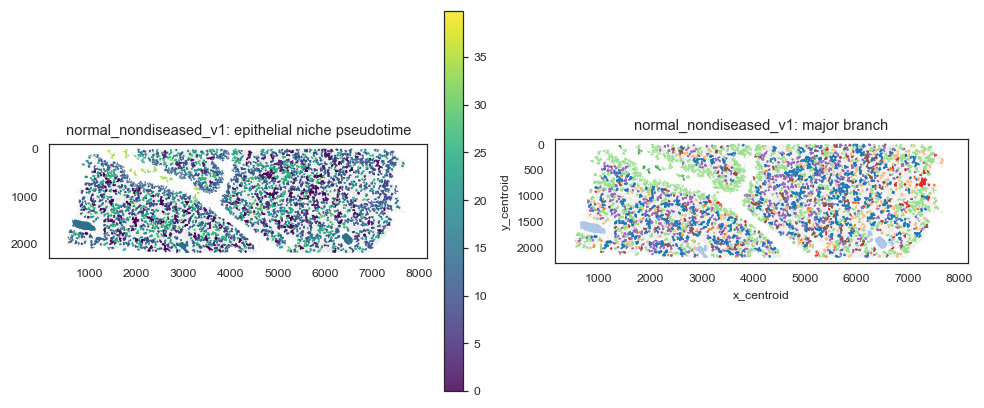

In [9]:

def plot_sample_spatial_pseudotime(sample_id, max_background=80000):
    adata_path = NICHE_DIR / f"{sample_id}_with_niches.h5ad"
    if not adata_path.exists():
        print(f"Missing niche AnnData for {sample_id}: {adata_path}")
        return
    adata = sc.read_h5ad(adata_path, backed="r")
    obs = adata.obs[["x_centroid", "y_centroid", NICHE_KEY, "Tier_A"]].copy()
    adata.file.close()

    lookup = result_df[result_df["sample_id"] == sample_id][[NICHE_KEY, "xenium_pseudotime", "major_branch"]].drop_duplicates()
    obs = obs.merge(lookup, on=NICHE_KEY, how="left")
    rng = np.random.default_rng(42)
    bg = obs
    if len(bg) > max_background:
        bg = bg.iloc[rng.choice(len(bg), size=max_background, replace=False)]
    niche = obs[obs["xenium_pseudotime"].notna()].copy()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].scatter(bg["x_centroid"], bg["y_centroid"], s=0.2, color="#d9d9d9", alpha=0.25, linewidth=0)
    sc0 = axes[0].scatter(
        niche["x_centroid"],
        niche["y_centroid"],
        c=niche["xenium_pseudotime"],
        s=0.8,
        cmap="viridis",
        linewidth=0,
        alpha=0.85,
    )
    axes[0].set_title(f"{sample_id}: epithelial niche pseudotime")
    axes[0].invert_yaxis()
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].grid(False)
    plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].scatter(bg["x_centroid"], bg["y_centroid"], s=0.2, color="#d9d9d9", alpha=0.25, linewidth=0)
    sns.scatterplot(
        data=niche,
        x="x_centroid",
        y="y_centroid",
        hue="major_branch",
        palette=branch_palette,
        s=1.0,
        linewidth=0,
        alpha=0.85,
        ax=axes[1],
        legend=False,
    )
    axes[1].set_title(f"{sample_id}: major branch")
    axes[1].invert_yaxis()
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()

for cfg in SAMPLE_CONFIGS:
    plot_sample_spatial_pseudotime(cfg["sample_id"])


In [10]:

save_df(result_df, RESULT_DIR / "xenium_pseudotime_result_df.pkl")
pd.Series(selected_cols, name="feature").to_csv(RESULT_DIR / "xenium_pseudotime_selected_features.csv", index=False)
with open(RESULT_DIR / "xenium_branch_definitions.json", "w") as f:
    json.dump(branch_defs, f, indent=2)
with open(RESULT_DIR / "xenium_tree_settings.json", "w") as f:
    json.dump(
        {
            "n_niches": int(n_niches),
            "detailed_num_nodes": int(num_nodes),
            "simplified_num_nodes": int(num_nodes_simple),
            "detailed_root_node": int(source_node),
            "simplified_root_node": int(source_node_simple),
            "detailed_tree_min_nodes": int(DETAILED_TREE_MIN_NODES),
            "detailed_tree_max_nodes": int(DETAILED_TREE_MAX_NODES),
            "detailed_tree_node_scale": float(DETAILED_TREE_NODE_SCALE),
        },
        f,
        indent=2,
    )

result_df.head()


,xenium_ductal_epithelium_component,sample_id,display_name,disease_group,UMAP1,UMAP2,xenium_pseudotime,xenium_node_id,xenium_edge_id,xenium_simple_pseudotime,xenium_simple_node_id,xenium_simple_edge_id,xenium_epithelial_identity_score,xenium_panin_like_remodeling_score,xenium_proliferation_score,xenium_desmoplastic_context_score,xenium_immune_context_score,xenium_checkpoint_context_score,xenium_nuclear_dapi_texture_score,major_branch
0,pdac_pancreas_v1__ductal_boundary_00001,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,8.925871,5.902560,22.594551,80,77,19.680915,22,19,0.411327,-0.193440,1.063498,1.092683,-0.687338,-0.360977,1.146233,branch 9
1,pdac_pancreas_v1__ductal_boundary_00002,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,10.697216,5.040128,27.299025,74,69,19.164133,22,19,0.627930,0.401430,0.797775,1.022966,0.925656,-0.330743,0.801687,branch 9
2,pdac_pancreas_v1__ductal_boundary_00003,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,9.518946,5.361968,19.722058,41,26,18.755399,22,19,1.471810,-0.139802,0.370625,0.972951,-0.212368,0.130757,0.618849,branch 9
3,pdac_pancreas_v1__ductal_boundary_00004,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,9.785358,4.855491,29.970357,86,83,24.377437,6,19,0.737255,-0.018592,4.228384,0.828356,-0.640156,0.343969,0.852054,branch 9
4,pdac_pancreas_v1__ductal_boundary_00005,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,8.882585,5.471994,22.594551,80,77,18.464050,22,19,0.767711,0.106994,0.003637,1.772549,2.217797,0.653788,1.158139,branch 9
